<a href="https://colab.research.google.com/github/Geetha1918/Predicting-Student-Performance-ML/blob/main/geetha_ml_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Load Dataset**

In [48]:
df = pd.read_csv('/content/StudentsPerformance.csv')

# **View Dataset**

In [49]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# **Check Shape**

In [50]:
df.shape

(1000, 8)

# **Check Columns**

In [51]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

# **Check Missing Values**

In [52]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


# **Data Cleaning**

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


# **Create Average Score Column**

In [54]:
df['average_score'] = (
      df['math score'] +
      df['reading score'] +
      df['writing score']
) / 3

# **Select Variables for SLR**

In [55]:
X = df[['reading score']]

y = df['math score']

# **Train Test Split**

In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **Train Linear Regression Model**

In [57]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

# **Predictions**

In [58]:
y_pred = lr.predict(X_test)

# **Best Fit Line**

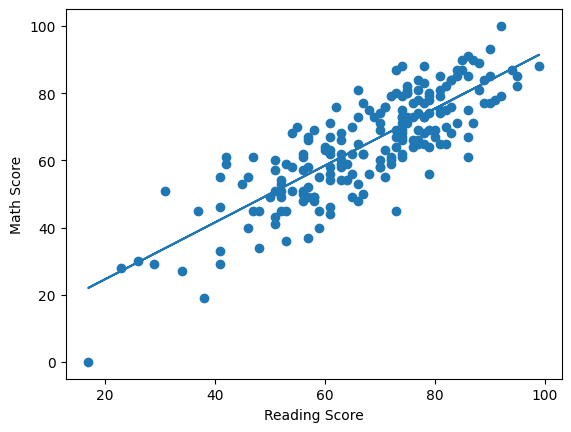

In [59]:
plt.scatter(X_test, y_test)

plt.plot(X_test, y_pred)

plt.xlabel("Reading Score")

plt.ylabel("Math Score")

plt.show()

# **Accuracy**

In [60]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

0.6804469009921283

# **Residual Analysis**

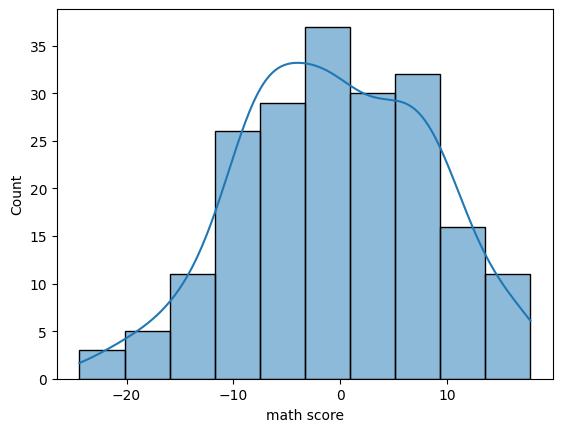

In [61]:
residuals = y_test - y_pred

sns.histplot(residuals, kde=True)

plt.show()

# **Select Multiple Features**

In [62]:
X = df[['reading score', 'writing score']]

y = df['math score']

# **Train Test Split**

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
)

# **Train MLR Model**

In [64]:
mlr = LinearRegression()

mlr.fit(X_train, y_train)

LinearRegression()

## **Predictions**

In [65]:
y_pred = mlr.predict(X_test)

# **Accuracy**

In [66]:
r2_score(y_test, y_pred)

0.6825697127424626

# **Correlation Matrix**

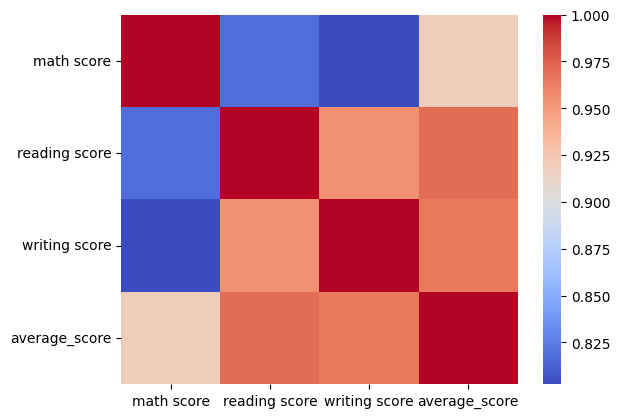

In [67]:
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')

plt.show()

# **Feature Selection using RFE**

In [68]:
from sklearn.feature_selection import RFE

model = LinearRegression()

rfe = RFE(model, n_features_to_select=1)

rfe.fit(X, y)

RFE(estimator=LinearRegression(), n_features_to_select=1)

## **Selected Features**

In [69]:
rfe.support_

array([ True, False])

# **Create Binary Target**

In [70]:
df['pass_fail'] = np.where(df['average_score'] >= 50, 1, 0)

# **Select Features**

In [71]:
X = df[['reading score', 'writing score']]

y = df['pass_fail']

# **Train Test Split**

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.2, random_state=42
)

# **Train Logistic Regression**

In [73]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

# **Predictions**

In [74]:
y_pred = log_model.predict(X_test)

# **Confusion Matrix**

In [75]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[ 24,   3],
       [  0, 173]])

# **Accuracy Score**

In [76]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.985

# **Classification Report**

In [77]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94        27
           1       0.98      1.00      0.99       173

    accuracy                           0.98       200
   macro avg       0.99      0.94      0.97       200
weighted avg       0.99      0.98      0.98       200



# **ROC Curve**

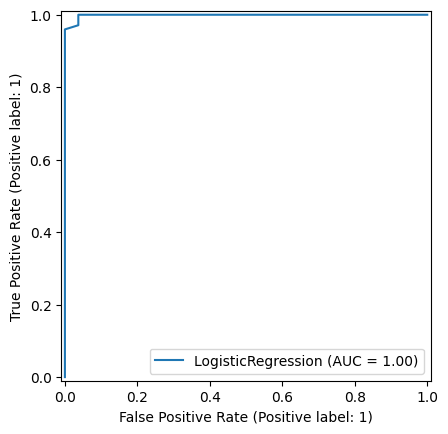

In [78]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(log_model, X_test, y_test)

plt.show()

# **Train Naive Bayes Model**

In [79]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

GaussianNB()

# **Predictions**

In [80]:
nb_pred = nb.predict(X_test)

# **Accuracy**

In [81]:
accuracy_score(y_test, nb_pred)

0.985

# **Select Features**

In [82]:
cluster_data = df[['math score', 'reading score']]

# **Scale Data**

In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

# **Elbow Method**

In [84]:
from sklearn.cluster import KMeans

sse = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    sse.append(kmeans.inertia_)

# **Plot Elbow Graph**

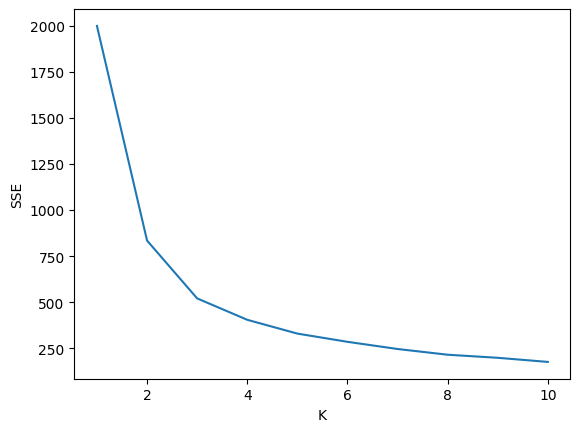

In [85]:
plt.plot(range(1,11), sse)

plt.xlabel("K")

plt.ylabel("SSE")

plt.show()

## **Apply K-Means**

In [86]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(scaled_data)

# **Visualize Clusters**

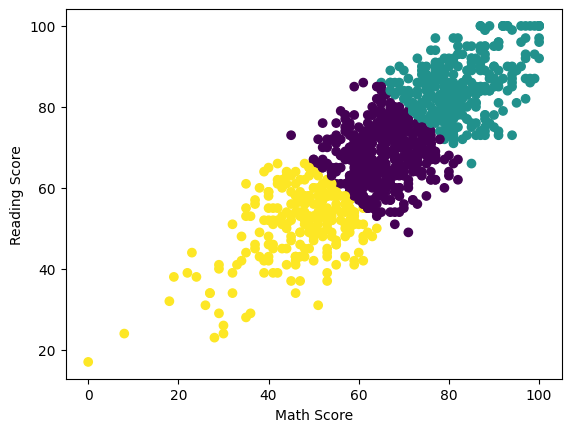

In [87]:
plt.scatter(df['math score'],
            df['reading score'],
                        c=df['Cluster'])

plt.xlabel("Math Score")

plt.ylabel("Reading Score")
plt.show()

# **Hierarchical Clustering**

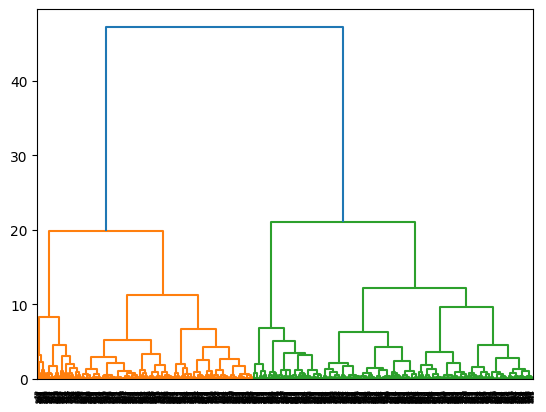

In [88]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(scaled_data, method='ward')

dendrogram(linked)

plt.show()

# **DBSCAN**

In [89]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5)

df['DBSCAN_Cluster'] = db.fit_predict(scaled_data)

# **PCA**

In [90]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

# **PCA Visualization**

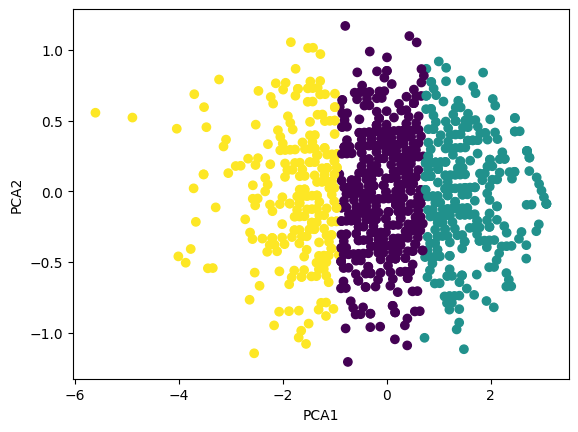

In [91]:
plt.scatter(pca_data[:,0],
            pca_data[:,1],
                        c=df['Cluster'])

plt.xlabel("PCA1")

plt.ylabel("PCA2")

plt.show()

# **Silhouette Score**

In [92]:
from sklearn.metrics import silhouette_score

silhouette_score(scaled_data, df['Cluster'])

np.float64(0.4204679825802347)